In [1]:
import random
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
from scipy import special
from tqdm import tqdm
from math import floor
import statsmodels.api as sm

# 1. Генерация данных

In [2]:
def gen():
    return int(np.random.random() * 10**6)

In [3]:
def generator_uniform(n):
    return np.random.uniform(-np.sqrt(3), np.sqrt(3), n)

def generator_normal(n):
    return np.random.normal(0, 1, n)

def generator_exponential(n):
    return stats.expon(scale=1, loc=-1).rvs(size=n, random_state=gen())

In [4]:
n = 100; N = 10**3
delta = 0.2

In [5]:
def get_exp_sequence(n):
    t = np.arange(n)

    return 5 * np.exp(-2 * t / n)

In [6]:
exp_sequence = get_exp_sequence(n)

data = {
    "uniform" : [generator_uniform(n) + exp_sequence for _ in range(N)],
    "normal" : [generator_normal(n) + exp_sequence for _ in range(N)],
    "exponential" : [generator_exponential(n) + exp_sequence for _ in range(N)]
}

# 2. Вычисление автокорреляционной функции

In [47]:
def get_autocorr_coef(array, lag):
    assert(lag < array.size - 1)

    inaccuracy = np.random.uniform(-delta, delta, array.shape[0])
    return stats.pearsonr(array[lag:] + inaccuracy[lag:], array[:-lag] + inaccuracy[:-lag])

def get_autocorr_coefs(array):
    return np.array([
        get_autocorr_coef(array, lag)[0] for lag in range(1, array.size - 1)
    ])

In [8]:
autocorr_coefs = {
    key : [get_autocorr_coefs(array) for array in tqdm(data[key])] for key in data.keys()
}

100%|██████████| 1000/1000 [00:46<00:00, 21.64it/s]


In [9]:
autocorr_coefs_min = {
    key : np.array([np.array(autocorr_coefs[key])[:, i].min() for i in range(n - 2)]) for key in data.keys()
}

autocorr_coefs_max = {
    key : np.array([np.array(autocorr_coefs[key])[:, i].max() for i in range(n - 2)]) for key in data.keys()
}

(-1.0, 1.0)

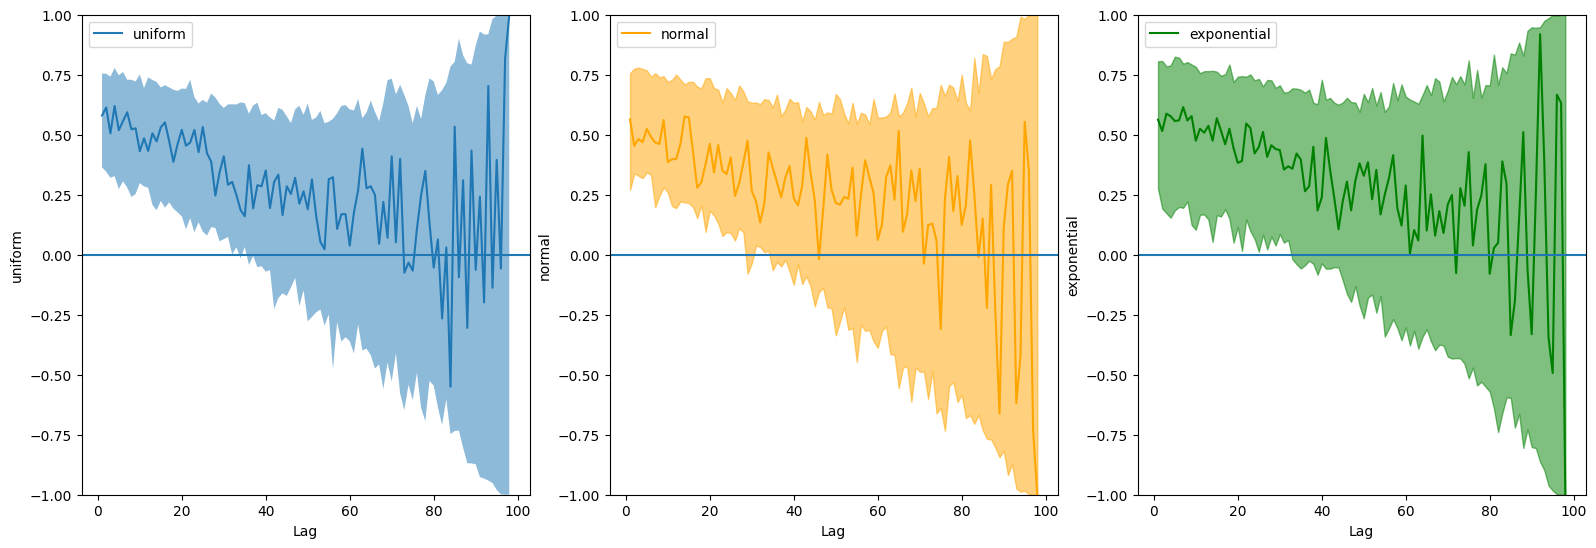

In [10]:
fig = plt.figure(figsize=(16, 6))

cell_width = 0.28
cell_height = 0.8
h_spacing = 0.05
bottom_margin = 0.1

ax1 = plt.axes([0.07, bottom_margin, cell_width, cell_height])
ax2 = plt.axes([0.07 + cell_width + h_spacing, bottom_margin, cell_width, cell_height])
ax3 = plt.axes([0.07 + 2*(cell_width + h_spacing), bottom_margin, cell_width, cell_height])

plt.sca(ax1)
key = "uniform"
sns.lineplot({key : autocorr_coefs[key][0], "Lag" : list(range(1, n - 1))}, y=key, x="Lag", label=key)
plt.fill_between(list(range(1, n - 1)), autocorr_coefs_min[key], autocorr_coefs_max[key], alpha=0.5)
plt.axhline(0)
plt.ylim(-1, 1)

plt.sca(ax2)
key = "normal"
sns.lineplot({key : autocorr_coefs[key][0], "Lag" : list(range(1, n - 1))}, y=key, x="Lag", label=key, color="orange")
plt.fill_between(list(range(1, n - 1)), autocorr_coefs_min[key], autocorr_coefs_max[key], alpha=0.5, color="orange")
plt.axhline(0)
plt.ylim(-1, 1)

plt.sca(ax3)
key = "exponential"
sns.lineplot({key : autocorr_coefs[key][0], "Lag" : list(range(1, n - 1))}, y=key, x="Lag", label=key, color="green")
plt.fill_between(list(range(1, n - 1)), autocorr_coefs_min[key], autocorr_coefs_max[key], alpha=0.5, color="green")
plt.axhline(0)
plt.ylim(-1, 1)

# 3. Начиная с какого $\tau$ ноль?

*Это лаг, начиная с которого, доверительный интервал автокорреляции по этому лагу не включает 0*

In [36]:
a, = autocorr_coefs_min['uniform'].shape

In [37]:
def get_tau(left_bounds, right_bounds):
    n, = left_bounds.shape
    l, r = 0, n - 1
    while (r - l) > 1:
        m = l + (r - l) // 2

        if left_bounds[m] <= 0 <= right_bounds[m]:
            r = m
        else:
            l = m

    return r

In [38]:
pd.DataFrame({
    key : [get_tau(autocorr_coefs_min[key], autocorr_coefs_max[key])] for key in data.keys()
}) # tau для наших выборок

,uniform,normal,exponential
0,33,34,32


In [54]:
def get_tau_array_from_experiment(data_generator, n=100, N=10**3):
    tau_array = np.zeros(N)
    for trial in tqdm(range(N)):
        data = [data_generator(n) + get_exp_sequence(n) for _ in range(N)]

        autocorr_coefs = [get_autocorr_coefs(array) for array in data]

        autocorr_coefs_min = np.array([np.array(autocorr_coefs)[:, i].min() for i in range(n - 2)])
        autocorr_coefs_max = np.array([np.array(autocorr_coefs)[:, i].max() for i in range(n - 2)])

        tau = get_tau(autocorr_coefs_min, autocorr_coefs_max)
        tau_array[trial] = tau
    return tau_array

In [56]:
tau_arrays = {
    "uniform" : get_tau_array_from_experiment(generator_uniform, N=10),
    "normal" : get_tau_array_from_experiment(generator_normal, N=10),
    "exponential" : get_tau_array_from_experiment(generator_exponential, N=10)
}

100%|██████████| 10/10 [00:05<00:00,  1.83it/s]


In [57]:
tau_arrays['uniform']

array([49., 48., 48., 58., 42., 36., 51., 49., 55., 48.])

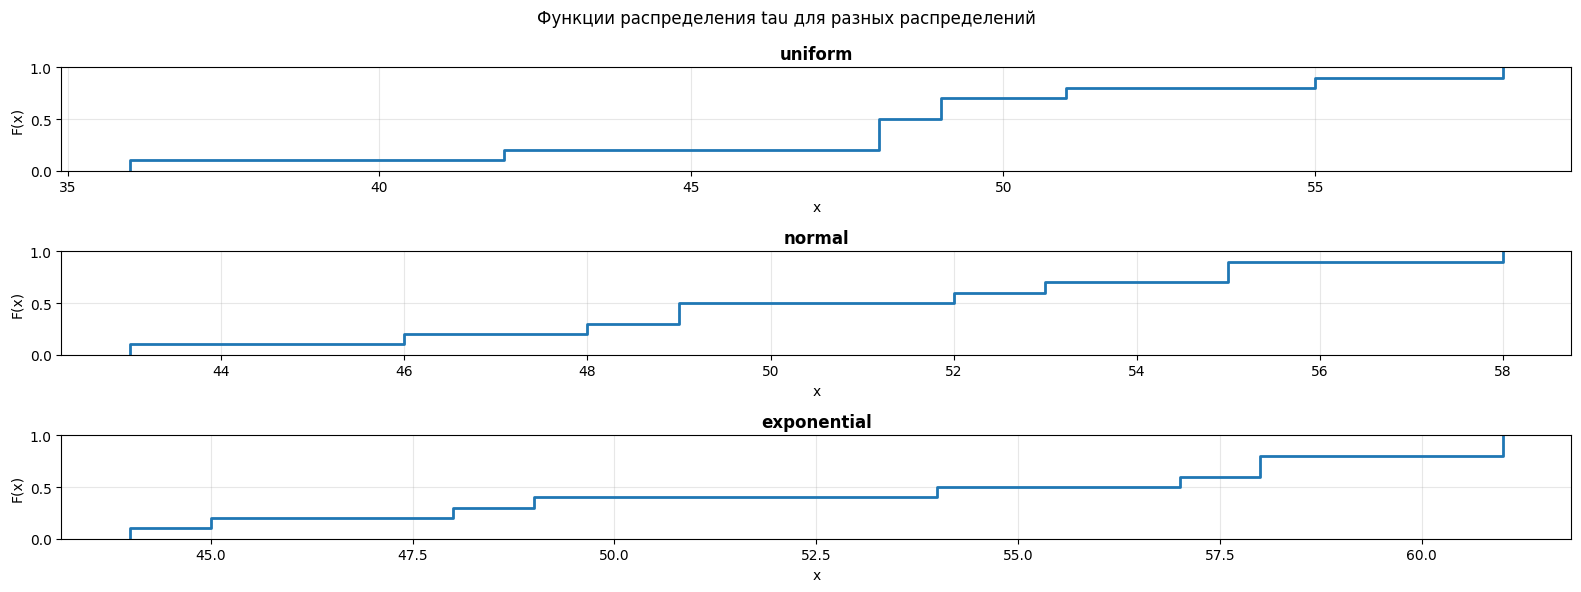

In [69]:
fig, axes = plt.subplots(3, 1, figsize=(16, 6))

fig.suptitle("Функции распределения tau для разных распределений")

# CDF для каждого массива
for i, (key, tau_array) in enumerate(tau_arrays.items()):
    ax=axes[i]
    sns.ecdfplot(data=tau_array, ax=ax, linewidth=2)
    ax.set_title(f'{key}', fontweight='bold')
    ax.set_xlabel('x')
    ax.set_ylabel('F(x)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()